In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyranges as pr
import glob as glob
import os
from importlib import reload
%matplotlib inline
import sys
sys.path.append("modules")
import bedgraph_tools as bgt
import peak_tools as pkt
from collections import defaultdict
import pyBigWig as pw
import pysam
from itertools import groupby
from Bio import motifs
import logomaker
from Bio import Align
from Bio.Seq import Seq
%config InlineBackend.figure_format='retina'
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
from scipy import stats
from scipy.interpolate import interp1d
import matplotlib.colors as mcolors
import upsetplot
from scipy.ndimage import uniform_filter
aligner = Align.PairwiseAligner()


/home/labs/barkailab/vovam/miniconda/envs/iran/lib/python3.11/site-packages/sorted_nearest/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [14]:
def filter_top_quantile(group, quantile=0.9):
    """
    Filters rows in a group where the sum across columns is above the quantile threshold.
    
    Parameters:
        group (pd.DataFrame): Grouped DataFrame.
        quantile (float): The quantile threshold (default 0.9).
        
    Returns:
        pd.DataFrame: Filtered DataFrame with top quantile rows.
    """
    # Compute the sum across all numeric columns per row
    # row_sums = group.loc[:, list(np.arange(75,95).astype(str)) + list(np.arange(105,125).astype(str))].sum(axis=1)
    row_sums = group.loc[:, list(np.arange(200).astype(str))].sum(axis=1)

    # Compute the quantile threshold
    threshold = np.quantile(row_sums, quantile)

    # Return rows that exceed the threshold
    return group[row_sums >= threshold]

def compute_footprint_lengths(x, y, thresholds):
    """
    Compute footprint lengths for multiple percentage thresholds.
    
    Parameters:
        x (array-like): X-values (time or index)
        y (array-like): Y-values (signal intensity)
        thresholds (list): List of percentage drop values (e.g., [0.05, 0.1, 0.5])

    Returns:
        footprint_lengths (dict): Dictionary with thresholds as keys and footprint lengths as values.
    """
    # Interpolation function
    interp_func = interp1d(x, y, kind='linear')

    # Generate more dense x values for interpolation
    window = 600
    x_dense = np.linspace(min(x), max(x), window)
    y_dense = interp_func(x_dense)  # Interpolated y values

    # Find Peak
    peak_index = int(window/2)
    peak_x = x_dense[peak_index]
    peak_y = y_dense[peak_index]

    footprint_lengths = {}

    for threshold in thresholds:
        threshold_value = threshold * peak_y  # Compute threshold level

        # Find left and right drop-off points safely
        left_indices = np.where(y_dense[:peak_index] <= threshold_value)[0]
        right_indices = np.where(y_dense[peak_index:] <= threshold_value)[0]

        left_x = x_dense[left_indices[-1]] if len(left_indices) > 0 else None
        right_x = x_dense[right_indices[0] + peak_index] if len(right_indices) > 0 else None

        # Compute footprint length if both sides exist
        footprint_length = right_x - left_x if left_x is not None and right_x is not None else None

        footprint_lengths[threshold] = footprint_length

    return footprint_lengths

def load_and_rename_mot(path, name):
    mot_enrich = pd.DataFrame(pd.read_csv(os.path.join(path, 'fimo.tsv'), delimiter='\t').iloc[:-3].set_index('sequence_name').loc[:, 'score']).reset_index().groupby('sequence_name').count()
    mot_enrich.columns = [name]
    return mot_enrich

In [17]:
order_pr = ['nmumg_hpr_del_lbd', 'nmumg_hpr_dlbd_dn100',
       'nmumg_hpr_dlbd_dn300', 'nmumg_hpr_dlbd_dn450', 'nmumg_hpr_dbd', ]
order_gr = ['nmumg_hgr_dlbd', 'nmumg_hgr_dlbd_dn50','nmumg_gr_dlbd_dn100', 
       'nmumg_hgr_dlbd_dn150', 'nmumg_hgr_dlbd_dn250', 'nmumg_hgr_dlbd_dn300', 'nmumg_hgr_dbd','nmumg_hgr_dlbd_dn400']

data1 = pd.read_parquet('data/cell_peaks_dbddlbdwtlig/nmumg_ar_trunc_clustered_peak_wsignals.parquet')
scols1 = ['nmumg_mar_dlbd','nmumg_ar_dlbd_dn100', 'nmumg_ar_dlbd_dn150', 'nmumg_ar_dlbd_dn200',
        'nmumg_mar_dlbd_dn300',
       'nmumg_mar_dlbd_dn350', 'nmumg_mar_dlbd_dn400', 'nmumg_mar_dlbd_dn450','nmumg_mar_dbd', ]
z = data1.set_index('nindex').loc[:, scols1]
z = (z-z.mean()) / z.std()

mot_folders = ['data/cell_peaks_dbddlbdwtlig/mot_enrich/NR_nmumg_ar_trunc_cluster', 
'data/cell_peaks_dbddlbdwtlig/mot_enrich/NR_hs_nmumg_ar_trunc_cluster',
'data/cell_peaks_dbddlbdwtlig/mot_enrich/AP1_nmumg_ar_trunc_cluster', 
'data/cell_peaks_dbddlbdwtlig/mot_enrich/FOX_nmumg_ar_trunc_cluster',
'data/cell_peaks_dbddlbdwtlig/mot_enrich/KLF_nmumg_ar_trunc_cluster',
'data/cell_peaks_dbddlbdwtlig/mot_enrich/RUNX_nmumg_ar_trunc_cluster',
'data/cell_peaks_dbddlbdwtlig/mot_enrich/TEAD_nmumg_ar_trunc_cluster',
              'data/cell_peaks_dbddlbdwtlig/mot_enrich/CTCF_nmumg_ar_trunc_cluster']

mots_enrich = pd.concat([load_and_rename_mot(x, x.split('/')[-1]) for x in mot_folders], axis=1)
clustered_w_motifs_ar = pd.concat([data1.set_index('nindex'), mots_enrich.fillna(0)], axis=1).fillna(0)


dl_ind_ar = list(z.query("nmumg_mar_dlbd>3 & nmumg_mar_dbd<2").sort_values(by='nmumg_mar_dlbd', ascending=False).index)
dbd_ind_ar = list(z.query("nmumg_mar_dlbd<2 & nmumg_mar_dbd>=3").sort_values(by='nmumg_mar_dbd', ascending=False).index)


data2 = pd.read_parquet('data/cell_peaks_dbddlbdwtlig/nmumg_pr_trunc_clustered_peak_wsignals.parquet')

z = data2.set_index('nindex').loc[:, order_pr]
z = (z-z.mean()) / z.std()

mot_folders = ['data/cell_peaks_dbddlbdwtlig/mot_enrich/NR_nmumg_pr_trunc_cluster', 
'data/cell_peaks_dbddlbdwtlig/mot_enrich/NR_hs_nmumg_pr_trunc_cluster',
'data/cell_peaks_dbddlbdwtlig/mot_enrich/AP1_nmumg_pr_trunc_cluster', 
'data/cell_peaks_dbddlbdwtlig/mot_enrich/FOX_nmumg_pr_trunc_cluster',
'data/cell_peaks_dbddlbdwtlig/mot_enrich/KLF_nmumg_pr_trunc_cluster',
'data/cell_peaks_dbddlbdwtlig/mot_enrich/RUNX_nmumg_pr_trunc_cluster',
'data/cell_peaks_dbddlbdwtlig/mot_enrich/TEAD_nmumg_pr_trunc_cluster',
'data/cell_peaks_dbddlbdwtlig/mot_enrich/CTCF_nmumg_pr_trunc_cluster' ]

mots_enrich = pd.concat([load_and_rename_mot(x, x.split('/')[-1]) for x in mot_folders], axis=1)
clustered_w_motifs_pr = pd.concat([data2.set_index('nindex'), mots_enrich.fillna(0)], axis=1).fillna(0)


dl_ind_pr = list(z.query("nmumg_hpr_del_lbd>3 & nmumg_hpr_dbd<2").sort_values(by='nmumg_hpr_del_lbd', ascending=False).index)
dbd_ind_pr = list(z.query("nmumg_hpr_del_lbd<2 & nmumg_hpr_dbd>=3").sort_values(by='nmumg_hpr_dbd', ascending=False).index)


data3 = pd.read_parquet('data/cell_peaks_dbddlbdwtlig/nmumg_gr_trunc_clustered_peak_wsignals.parquet')

z = data3.set_index('nindex').loc[:, order_gr]
z = (z-z.mean()) / z.std()

mot_folders = ['data/cell_peaks_dbddlbdwtlig/mot_enrich/NR_nmumg_gr_trunc_cluster', 
'data/cell_peaks_dbddlbdwtlig/mot_enrich/NR_hs_nmumg_gr_trunc_cluster',
'data/cell_peaks_dbddlbdwtlig/mot_enrich/AP1_nmumg_gr_trunc_cluster', 
'data/cell_peaks_dbddlbdwtlig/mot_enrich/FOX_nmumg_gr_trunc_cluster',
'data/cell_peaks_dbddlbdwtlig/mot_enrich/KLF_nmumg_gr_trunc_cluster',
'data/cell_peaks_dbddlbdwtlig/mot_enrich/RUNX_nmumg_gr_trunc_cluster',
'data/cell_peaks_dbddlbdwtlig/mot_enrich/TEAD_nmumg_gr_trunc_cluster',
'data/cell_peaks_dbddlbdwtlig/mot_enrich/CTCF_nmumg_gr_trunc_cluster' ]

mots_enrich = pd.concat([load_and_rename_mot(x, x.split('/')[-1]) for x in mot_folders], axis=1)
clustered_w_motifs_gr = pd.concat([data3.set_index('nindex'), mots_enrich.fillna(0)], axis=1).fillna(0)


dl_ind_gr = list(z.query("nmumg_hgr_dlbd>3 & nmumg_hgr_dlbd_dn400<2").sort_values(by='nmumg_hgr_dlbd', ascending=False).index)
dbd_ind_gr = list(z.query("nmumg_hgr_dlbd<2 & nmumg_hgr_dlbd_dn400>=3").sort_values(by='nmumg_hgr_dlbd_dn400', ascending=False).index)

/tmp/ipykernel_917081/449324218.py:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x1.loc[i],y1.loc[i], label=i, c=pal[i], s=30,  zorder=20, marker='p')
/tmp/ipykernel_917081/449324218.py:20: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x2.loc[i],y2.loc[i], label=i, c=pal[i], s=30, zorder=20, marker='s')
/tmp/ipykernel_917081/449324218.py:28: UserWarning: *c* argument looks like a single numeric RGB 

Text(0, 0.5, 'DBD')

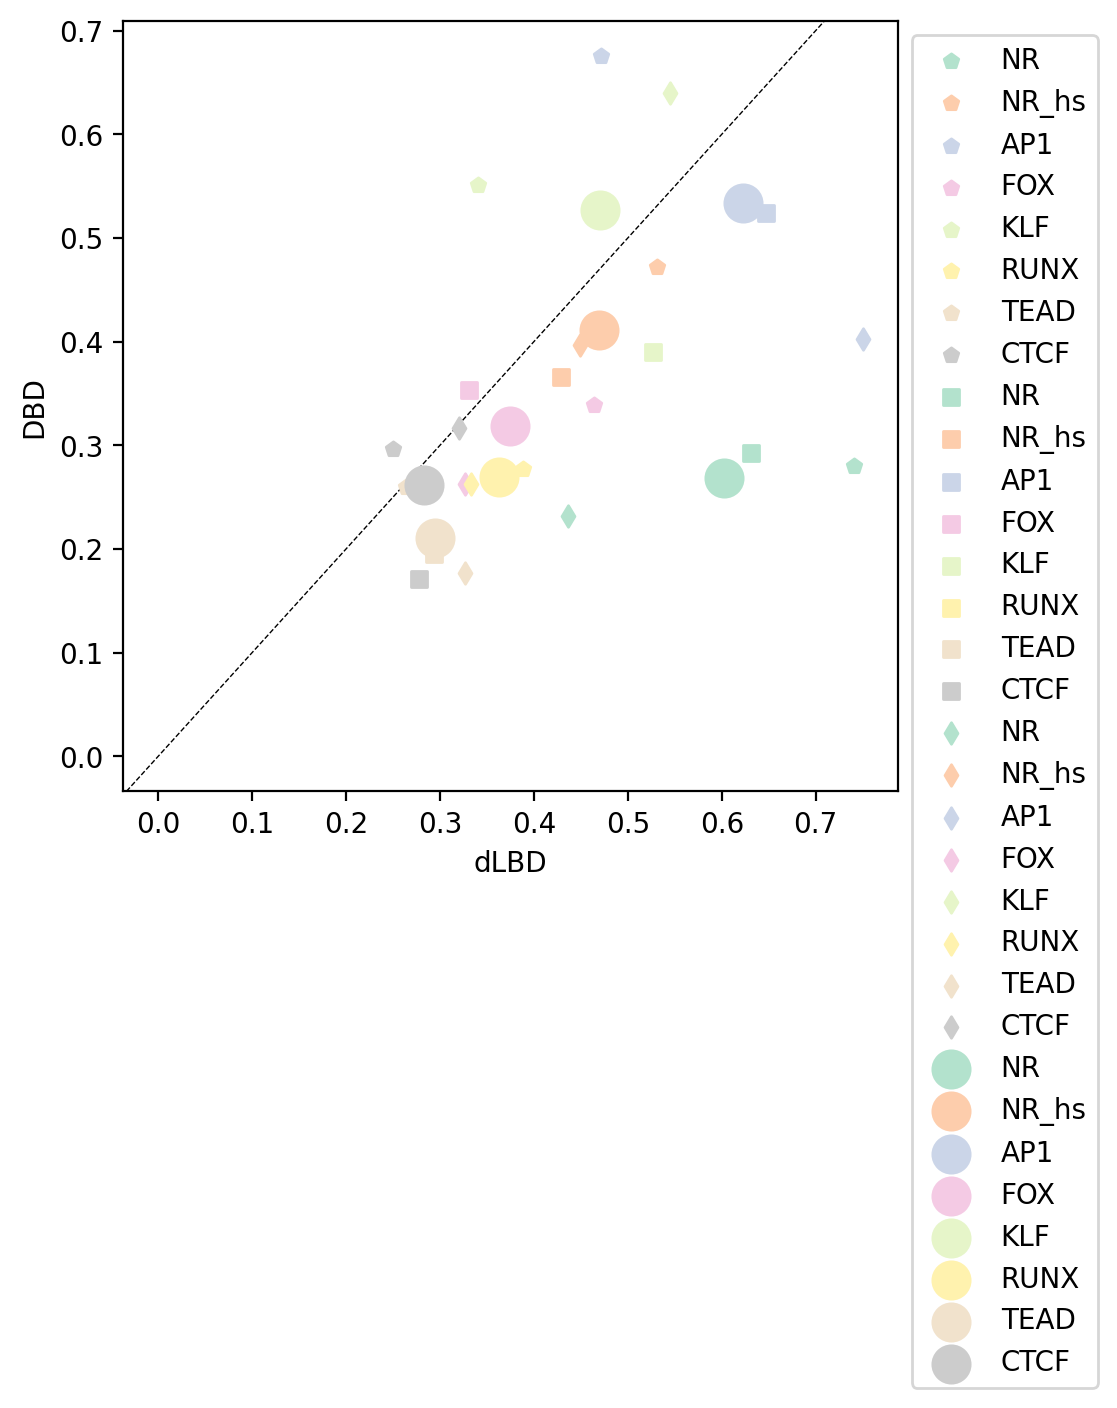

In [18]:
fig, ax = plt.subplots(1, figsize=(5,5))

x1 = pd.DataFrame(((clustered_w_motifs_ar.loc[dl_ind_ar].filter(regex='cluster')>0).sum() / len(dl_ind_ar)))
y1 = pd.DataFrame(((clustered_w_motifs_ar.loc[dbd_ind_ar].filter(regex='cluster')>0).sum() / len(dbd_ind_ar)))
y1.index = [x.split('_nm')[0] for x in y1.index]
x1.index = [x.split('_nm')[0] for x in x1.index]

pal = dict(zip(x1.index, sns.color_palette('Pastel2', n_colors=x1.index.shape[0])))

for i in x1.index:
    ax.scatter(x1.loc[i],y1.loc[i], label=i, c=pal[i], s=30,  zorder=20, marker='p')

    

x2 = pd.DataFrame(((clustered_w_motifs_pr.loc[dl_ind_pr].filter(regex='cluster')>0).sum() / len(dl_ind_pr)))
y2 = pd.DataFrame(((clustered_w_motifs_pr.loc[dbd_ind_pr].filter(regex='cluster')>0).sum() / len(dbd_ind_pr)))
y2.index = [x.split('_nm')[0] for x in y2.index]
x2.index = [x.split('_nm')[0] for x in x2.index]
for i in x1.index:
    ax.scatter(x2.loc[i],y2.loc[i], label=i, c=pal[i], s=30, zorder=20, marker='s')
    

x3 = pd.DataFrame(((clustered_w_motifs_gr.loc[dl_ind_gr].filter(regex='cluster')>0).sum() / len(dl_ind_gr)))
y3 = pd.DataFrame(((clustered_w_motifs_gr.loc[dbd_ind_gr].filter(regex='cluster')>0).sum() / len(dbd_ind_gr)))
y3.index = [x.split('_nm')[0] for x in y3.index]
x3.index = [x.split('_nm')[0] for x in x3.index]
for i in x1.index:
    ax.scatter(x3.loc[i],y3.loc[i], label=i, c=pal[i], s=30, zorder=20, marker='d')
    
    
    
x = pd.DataFrame(pd.concat([x1,x2,x3], axis=1).mean(axis=1))
y = pd.DataFrame(pd.concat([y1,y2,y3], axis=1).mean(axis=1))
y.index = [x.split('_nm')[0] for x in y.index]
x.index = [x.split('_nm')[0] for x in x.index]
for i in x1.index:
    ax.scatter(x.loc[i],y.loc[i], label=i, c=pal[i], s=180, zorder=20)

ax.axline((0,0), slope=1, zorder=1, ls='--', c='k', lw=.5)

ax.legend(bbox_to_anchor=[1,1])
ax.set_xlabel('dLBD')
ax.set_ylabel('DBD')
# fig.savefig('figures/Fig6/6D.pdf')

In [6]:
mot_signals = ['data/cell_peaks_dbddlbdwtlig/ar_trunc_nmumg_mar_dlbd_signals_on_motifs.parquet',
 'data/cell_peaks_dbddlbdwtlig/gr_trunc_nmumg_hgr_dlbd_signals_on_motifs.parquet','data/cell_peaks_dbddlbdwtlig/pr_trunc_nmumg_hpr_del_lbd_signals_on_motifs.parquet',
    'data/cell_peaks_dbddlbdwtlig/gr_trunc_nmumg_hgr_dbd_signals_on_motifs.parquet',
 'data/cell_peaks_dbddlbdwtlig/pr_trunc_nmumg_hpr_dbd_signals_on_motifs.parquet',
 'data/cell_peaks_dbddlbdwtlig/ar_trunc_nmumg_mar_dbd_signals_on_motifs.parquet',
              'data/cell_peaks_dbddlbdwtlig/wt_ligand_nmumg_smad1_bmp_high_signals_on_motifs.parquet']

forhtmp = dict()
alldf = pd.DataFrame()
allfoot_df = pd.DataFrame()
for sig in mot_signals:
    a = pd.read_parquet(sig)
    # analyzed = a.loc[:, ['id'] + list(np.arange(200).astype(str))].groupby('id', group_keys=False).apply(filter_top_quantile, 0.9).groupby('id').mean().T
    analyzed = a.loc[:, ['id'] + list(np.arange(200).astype(str))]
    foot_df = pd.DataFrame()
    for idi in analyzed.id.unique():
        proc_df = filter_top_quantile(analyzed[analyzed.id == idi].loc[:, np.arange(200).astype(str)], 0.9)
        forhtmp[idi+sig.split('/')[-1].split('__signals')[0].replace('nmumg_', '')] = proc_df
        top5_cols = (
                proc_df.iloc[:, :200]
                .mean()
                .sort_values(ascending=False)
                .iloc[:5]
                .index
                .astype(int)
            )
        null = proc_df.iloc[:, top5_cols].values.flatten()
        func = lambda x: stats.mannwhitneyu(null, x)[1]
        calc_pvs = proc_df.iloc[:, :200].apply(func, axis=0)
        calc_pvs[(calc_pvs == 0)] = calc_pvs[~(calc_pvs == 0)].min()
        m10log10pval = (-10 * np.log10(calc_pvs))
        
        foot  = pd.DataFrame(compute_footprint_lengths(m10log10pval.index.astype(int), m10log10pval, np.arange(0.05,1.05,0.05)), index=[idi]).T
        foot_df = pd.concat([foot_df, foot], axis=1)
    analyzed = analyzed.groupby('id', group_keys=False).apply(filter_top_quantile, 0.9).groupby('id').mean().T
    analyzed.columns = [x+ '_' + sig.split('/')[-1].split('__signals')[0].replace('nmumg_', '') for x in analyzed.columns]
    foot_df.columns = [x+ '_' + sig.split('/')[-1].split('__signals')[0].replace('nmumg_', '') for x in foot_df.columns]

    alldf = pd.concat([alldf, analyzed], axis=1)
    allfoot_df = pd.concat([allfoot_df, foot_df], axis=1)

/tmp/ipykernel_917081/2136118855.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  analyzed = analyzed.groupby('id', group_keys=False).apply(filter_top_quantile, 0.9).groupby('id').mean().T
/tmp/ipykernel_917081/2136118855.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  analyzed = analyzed.groupby('id', group_keys=False).apply(filter_top_quantile, 0.9).groupby('id').mean().T
/tmp/ipykernel_917081/2136118855.p

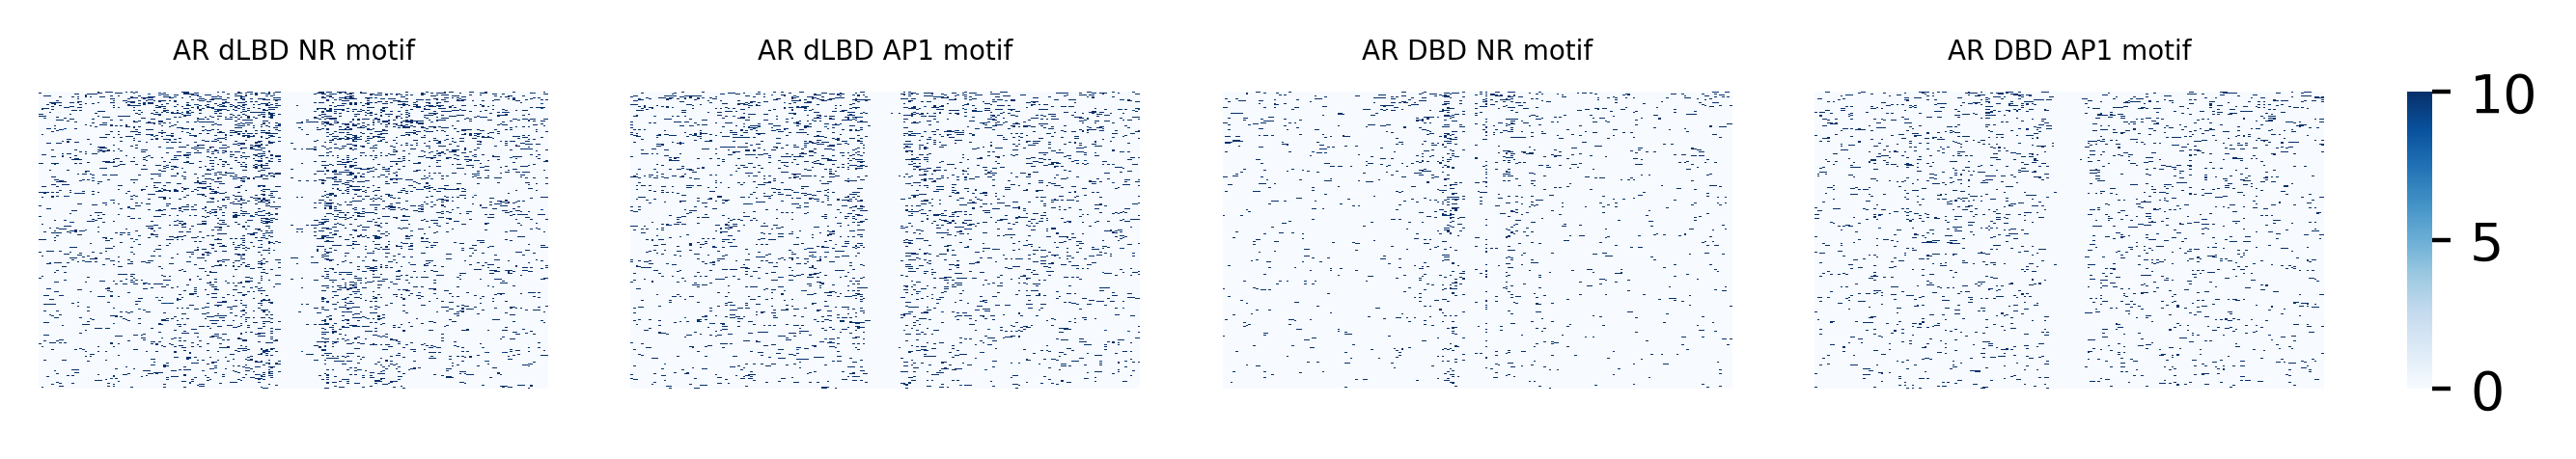

In [12]:
fig, ax = plt.subplots(1,5, width_ratios=[5,5,5,5,.25], figsize=(8,1), dpi=200)

indices = forhtmp['GR_NRar_trunc_mar_dlbd_signals_on_motifs.parquet'].sum(axis=1).sort_values(ascending=False).index
sns.heatmap(forhtmp['GR_NRar_trunc_mar_dlbd_signals_on_motifs.parquet'].loc[indices],
            cmap='Blues', vmin=0, vmax=10, ax=ax[0], yticklabels=False, xticklabels=False, cbar_ax = ax[-1], rasterized=True)

indices = forhtmp['GR_AP1ar_trunc_mar_dlbd_signals_on_motifs.parquet'].sum(axis=1).sort_values(ascending=False).index
sns.heatmap(forhtmp['GR_AP1ar_trunc_mar_dlbd_signals_on_motifs.parquet'].loc[indices],
            cmap='Blues', vmin=0, vmax=10, ax=ax[1], yticklabels=False, xticklabels=False, cbar=False, rasterized=True)

indices = forhtmp['GR_NRar_trunc_mar_dbd_signals_on_motifs.parquet'].sum(axis=1).sort_values(ascending=False).index
sns.heatmap(forhtmp['GR_NRar_trunc_mar_dbd_signals_on_motifs.parquet'].loc[indices],
            cmap='Blues', vmin=0, vmax=10, ax=ax[2], yticklabels=False, xticklabels=False, cbar=False, rasterized=True)

indices = forhtmp['GR_AP1ar_trunc_mar_dbd_signals_on_motifs.parquet'].sum(axis=1).sort_values(ascending=False).index
sns.heatmap(forhtmp['GR_AP1ar_trunc_mar_dbd_signals_on_motifs.parquet'].loc[indices],
            cmap='Blues', vmin=0, vmax=10, ax=ax[3], yticklabels=False, xticklabels=False, cbar=False, rasterized=True)

ax[0].set_title("AR dLBD NR motif", size=5)
ax[1].set_title("AR dLBD AP1 motif", size=5)
ax[2].set_title("AR DBD NR motif", size=5)
ax[3].set_title("AR DBD AP1 motif", size=5)



fig.savefig('figures/Fig5/5B.pdf')


/tmp/ipykernel_917081/2328909635.py:9: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=0)
/tmp/ipykernel_917081/2328909635.py:17: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  subf[ind].subplots_adjust(hspace=0)
/tmp/ipykernel_917081/2328909635.py:17: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  subf[ind].subplots_adjust(hspace=0)
/tmp/ipykernel_917081/2328909635.py:17: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  subf[ind].subplots_adjust(hspace=0)
/tmp/ipykernel_917081/2328909635.py:17: UserWarning: This figure was using a layout engine that is incompatible with subplo

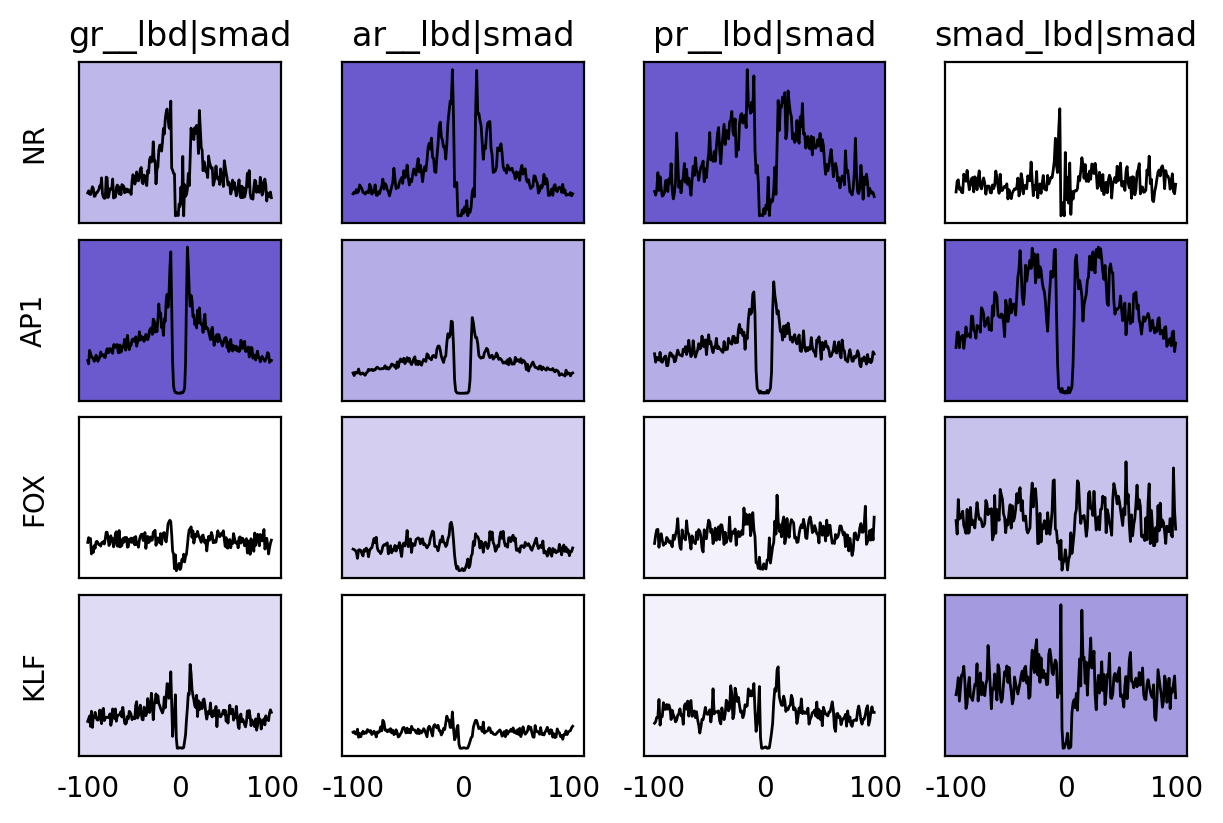

In [24]:
mottype = ['NR', 'AP1', 'FOX',  'KLF',]
tftype =['gr_', 'ar_', 'pr_', 'smad']
muttype = ['lbd|smad']

colormap = sns.blend_palette(['white', 'slateblue'], as_cmap=True)
fig = plt.figure(figsize=(6,4), constrained_layout=True)

subf = fig.subfigures(1,4)
fig.subplots_adjust(wspace=0)
ind = 0

# palette = ['purple', 'slateblue', 'palevioletred', 'cadetblue']
for mut in muttype:
    for tf in tftype:
        tfmut = alldf.filter(regex=mut).filter(regex=tf)
        axes = subf[ind].subplots(len(mottype),1,sharey=True, sharex=True)
        subf[ind].subplots_adjust(hspace=0)
        axes[0].set_title(f'{tf}_{mut}')
        for mot, axi in zip(mottype, axes):
            to_plot = tfmut.filter(regex=mot)
            
            axi.plot(to_plot, c='k', lw=1)
            axi.set_yticklabels('')
            norm = plt.Normalize(vmin=tfmut.mean().min(), vmax=tfmut.mean().max())
            background_color = colormap(norm(to_plot.mean()))
            axi.set_facecolor(background_color)
            axi.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False)
            if ind == 0:
                axi.set_ylabel(mot)
        axi.set_xticks(np.arange(0,300,100), np.arange(-100,200,100))
        ind += 1
fig.savefig('figures/Fig5/5E.pdf')

In [25]:
mot_signals = ['data/cell_peaks_dbddlbdwtlig/ar_trunc_nmumg_mar_dlbd_signals_on_motifs.parquet',
    'data/cell_peaks_dbddlbdwtlig/ar_trunc_nmumg_ar_dlbd_dn100_signals_on_motifs.parquet',
 'data/cell_peaks_dbddlbdwtlig/ar_trunc_nmumg_ar_dlbd_dn150_signals_on_motifs.parquet',
 'data/cell_peaks_dbddlbdwtlig/ar_trunc_nmumg_ar_dlbd_dn200_signals_on_motifs.parquet',
 'data/cell_peaks_dbddlbdwtlig/ar_trunc_nmumg_mar_dlbd_dn300_signals_on_motifs.parquet',
 'data/cell_peaks_dbddlbdwtlig/ar_trunc_nmumg_mar_dlbd_dn350_signals_on_motifs.parquet',
 'data/cell_peaks_dbddlbdwtlig/ar_trunc_nmumg_mar_dlbd_dn400_signals_on_motifs.parquet',
 'data/cell_peaks_dbddlbdwtlig/ar_trunc_nmumg_mar_dlbd_dn450_signals_on_motifs.parquet',
  'data/cell_peaks_dbddlbdwtlig/ar_trunc_nmumg_mar_dbd_signals_on_motifs.parquet',

 ]
alldf = pd.DataFrame()
allfoot_df = pd.DataFrame()
for sig in mot_signals:
    a = pd.read_parquet(sig)
    analyzed = a.loc[:, ['id'] + list(np.arange(200).astype(str))]
    foot_df = pd.DataFrame()
    for idi in analyzed.id.unique():
        proc_df = filter_top_quantile(analyzed[analyzed.id == idi].loc[:, np.arange(200).astype(str)], 0.9)
        top5_cols = (
                proc_df.iloc[:, :200]
                .mean()
                .sort_values(ascending=False)
                .iloc[:5]
                .index
                .astype(int)
            )
        null = proc_df.iloc[:, top5_cols].values.flatten()
        func = lambda x: stats.mannwhitneyu(null, x)[1]
        calc_pvs = proc_df.iloc[:, :200].apply(func, axis=0)
        calc_pvs[(calc_pvs == 0)] = calc_pvs[~(calc_pvs == 0)].min()
        m10log10pval = (-10 * np.log10(calc_pvs))
        
        foot  = pd.DataFrame(compute_footprint_lengths(m10log10pval.index.astype(int), m10log10pval, np.arange(0.05,1.05,0.05)), index=[idi]).T
        foot_df = pd.concat([foot_df, foot], axis=1)
    analyzed = analyzed.groupby('id', group_keys=False).apply(filter_top_quantile, 0.9).groupby('id').mean().T
    analyzed.columns = [x+ '_' + sig.split('/')[-1].split('__signals')[0].replace('nmumg_', '') for x in analyzed.columns]
    foot_df.columns = [x+ '_' + sig.split('/')[-1].split('__signals')[0].replace('nmumg_', '') for x in foot_df.columns]

    alldf = pd.concat([alldf, analyzed], axis=1)
    allfoot_df = pd.concat([allfoot_df, foot_df], axis=1)

/tmp/ipykernel_917081/3812206403.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  analyzed = analyzed.groupby('id', group_keys=False).apply(filter_top_quantile, 0.9).groupby('id').mean().T
/tmp/ipykernel_917081/3812206403.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  analyzed = analyzed.groupby('id', group_keys=False).apply(filter_top_quantile, 0.9).groupby('id').mean().T
/tmp/ipykernel_917081/3812206403.p

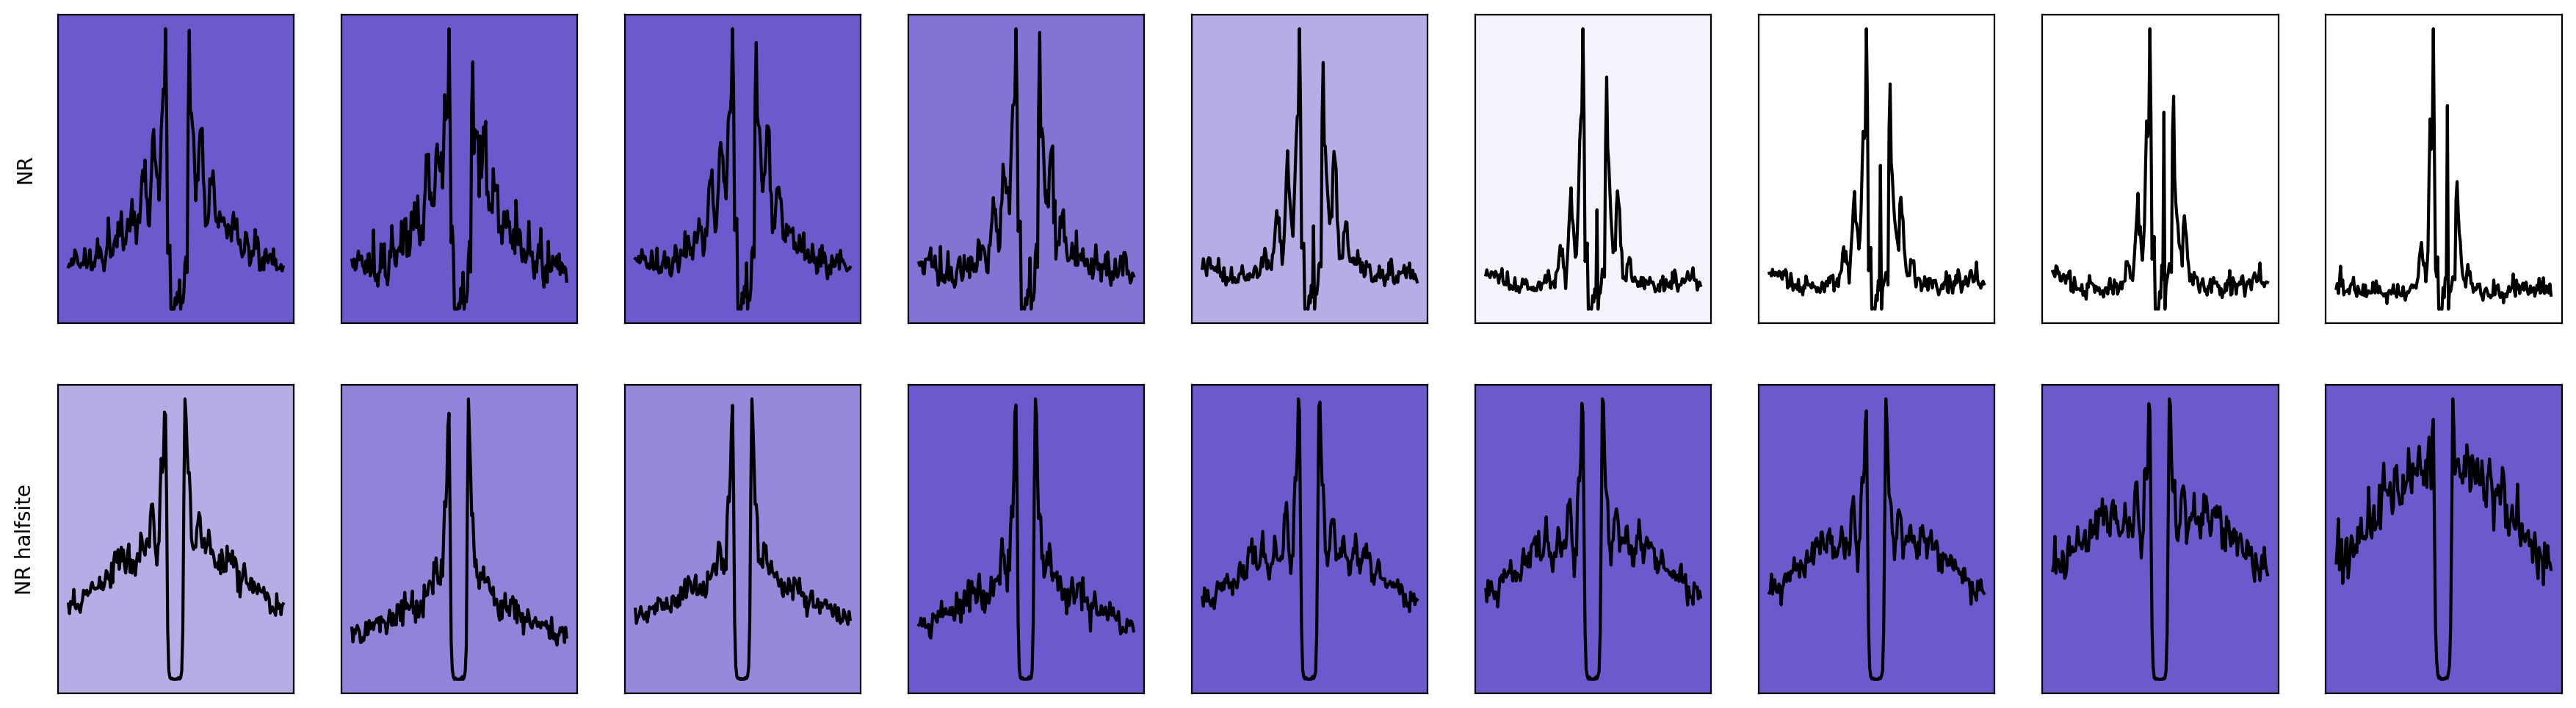

In [42]:
labels = ['nmumg_mar_dlbd', 'nmumg_ar_dlbd_dn100', 'nmumg_ar_dlbd_dn150',
       'nmumg_ar_dlbd_dn200', 'nmumg_mar_dlbd_dn300', 'nmumg_mar_dlbd_dn350',
       'nmumg_mar_dlbd_dn400', 'nmumg_mar_dlbd_dn450', 'nmumg_mar_dbd']

from itertools import repeat
maxesd = dict()
mind = dict()
lim_d = dict()
extend = []
for label in labels:
    extend.extend([label]*7)
label_sampled = pd.DataFrame(dict(zip(alldf.columns, extend)), index=['label']).T.reset_index().groupby('label').agg(lambda x: list(x)).squeeze().to_dict()

for key, values in label_sampled.items():
    max_val = alldf.loc[:, values].mean().max()
    min_val = alldf.loc[:, values].mean().min()

    maxesd.update(dict(zip(values, repeat(max_val))))
    mind.update(dict(zip(values, repeat(min_val))))
    lim_d.update(dict(zip(values, repeat(alldf.loc[:, values].max().max()))))
fig, ax = plt.subplots(2,len(mot_signals), sharex=False, figsize=(22,6))

# for i, axrow in zip(['NR','halfsite', 'FOX', 'AP1', 'KLF', ], ax, ):
for i, axrow in zip(['NR','AP1'], ax, ):
    name = alldf.filter(regex=i).columns
    for namei, axcol in zip(name, axrow):
        ad = alldf.loc[:, namei]
        norm = plt.Normalize(vmin=mind[namei], vmax=maxesd[namei])

        
        axcol.plot(ad,  label=namei, c='k')
        # axcol.set_ylim([-2, lim_d[namei]])
        axcol.set_xticklabels('')
        axcol.set_yticklabels('')
        background_color = colormap(norm(ad.mean()))
        axcol.set_facecolor(background_color)
        axcol.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False)
        if i ==' NR':
            axcol.set_title(namei.split('_signals_on')[0].split('trunc_')[1])
            

ax[0][0].set_ylabel("NR")
ax[1][0].set_ylabel("NR halfsite")
# ax[2][0].set_ylabel("FOX")
# ax[3][0].set_ylabel("AP1")
# ax[4][0].set_ylabel("KLF")

fig.savefig('figures/Fig5/5CDF.pdf')


/tmp/ipykernel_917081/1329326570.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


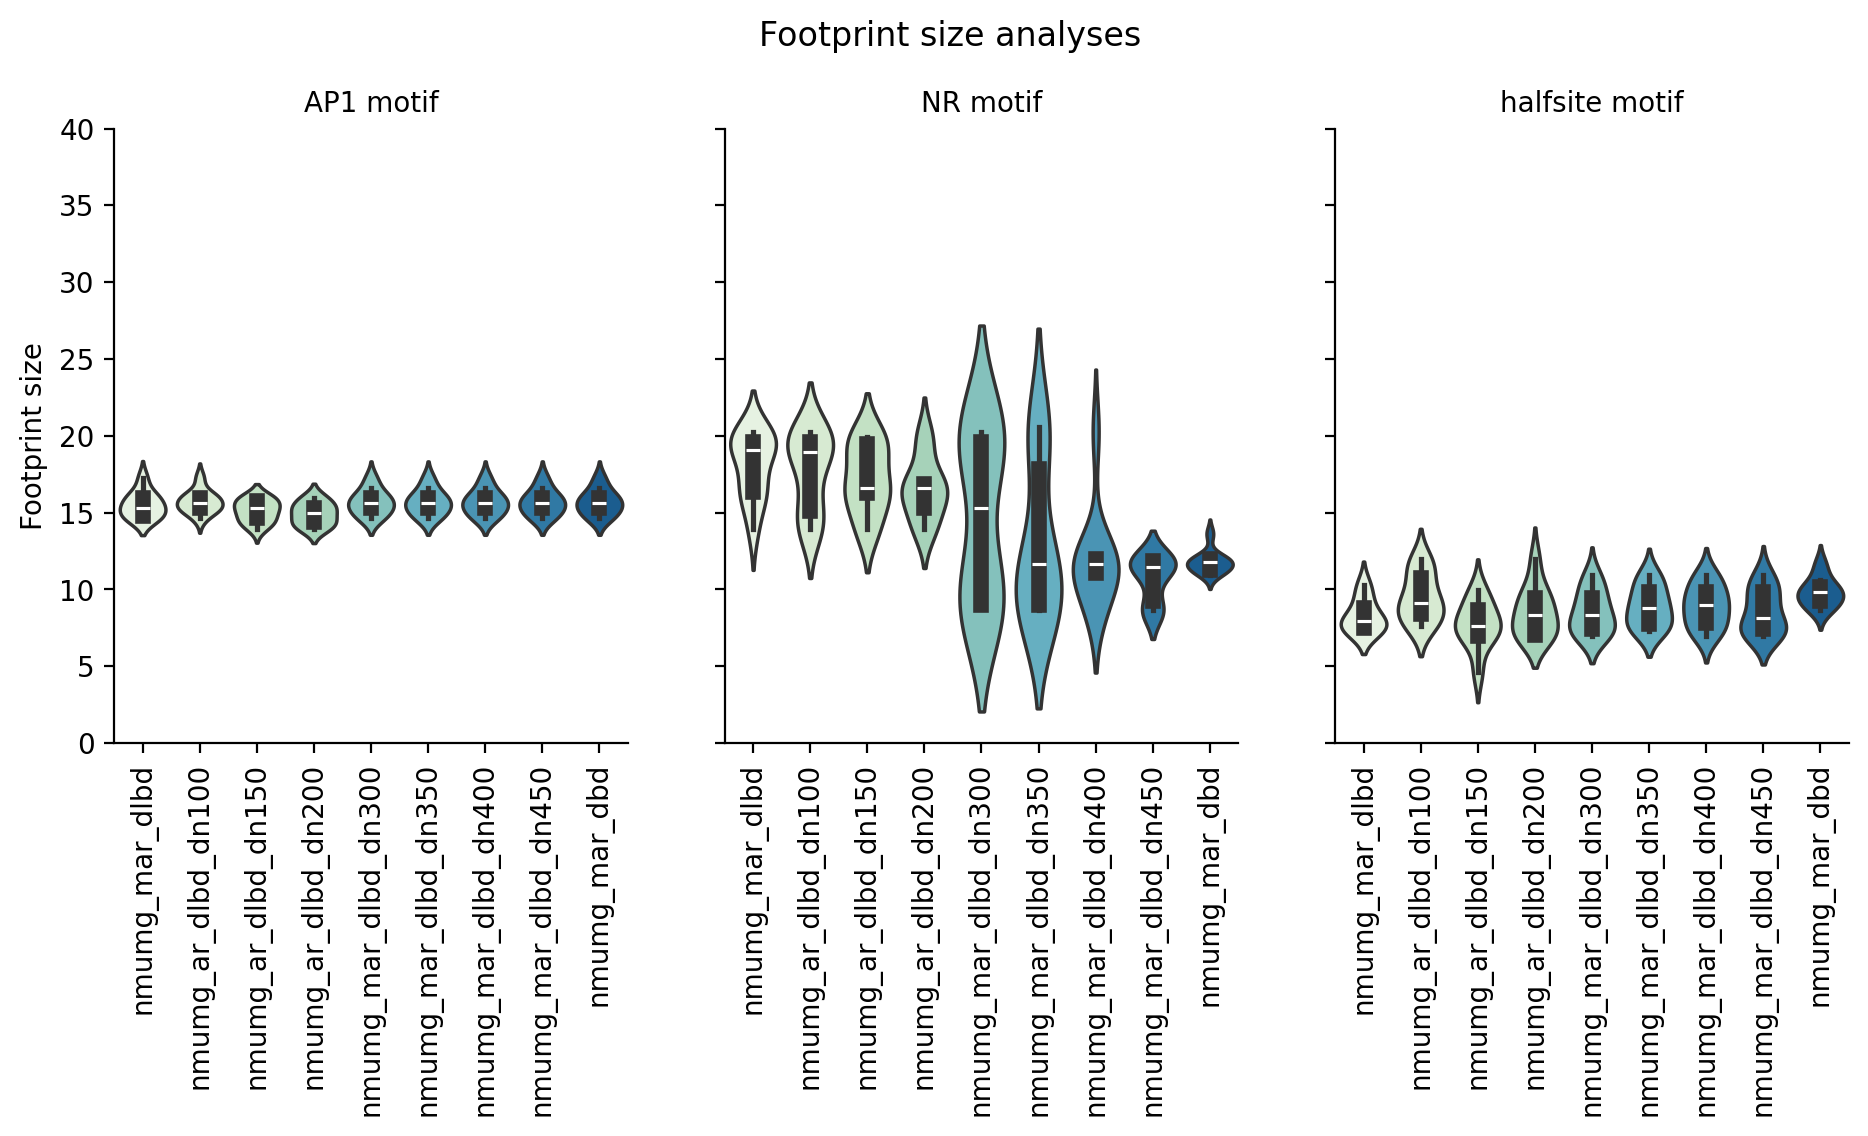

In [32]:
# unstacked = allfoot_df.loc[0.3:0.75].unstack().reset_index()
unstacked = allfoot_df.iloc[:10,:].filter(regex='AP1|NR|halfsite').unstack().reset_index()

unstacked.loc[:, 'motif'] = unstacked.level_0.apply(lambda x: x.split('_')[1])
unstacked.loc[:, 'factor'] = unstacked.level_0.apply(lambda x: x.split('_sig')[0].split('trunc_')[1])
# unstacked.loc[:, 'type'] = unstacked.factor.apply(lambda x: '_'.join(x.split('_')[1:]))
unstacked = unstacked.drop('level_0', axis=1)
unstacked.replace('del_lbd', 'dlbd', inplace=True)

g = sns.catplot(
    unstacked, kind="violin",
    col="motif", y=0, x="factor",
    height=4, aspect=.8, sharey=True,native_scale=True, palette='GnBu'
)
g.set_axis_labels("", "Footprint size")
g.set_xticklabels(labels, rotation=90)
g.set(ylim=(0, 40))

g.set_titles("{col_name} {col_var}")
g.fig.suptitle("Footprint size analyses", y=1.05)  # Adjust y to control the vertical position
g.figure.savefig('figures/Fig5/5G.pdf')


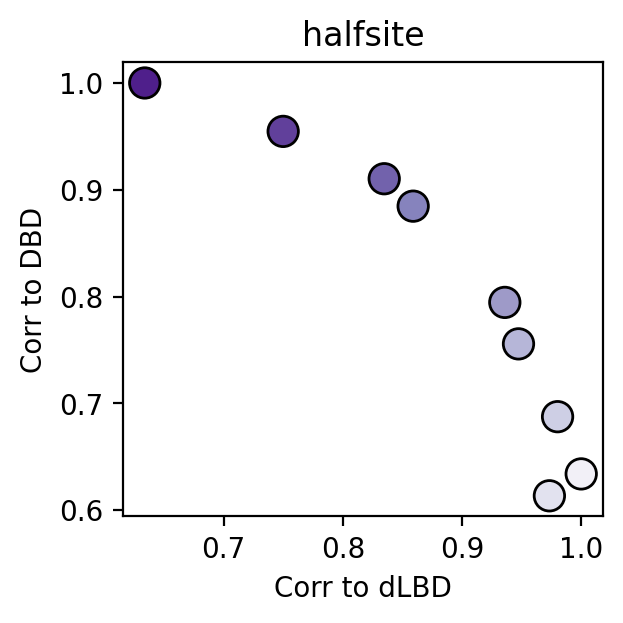

In [38]:
ids=['NR']

cd = sns.color_palette('Purples', n_colors=len(labels))
all_corr = alldf.corr()

fig, axi = plt.subplots(1,1, sharex=True, sharey=True, constrained_layout=True, figsize=(3,3))
axi.scatter(alldf.filter(regex=ids[0]).corr().iloc[:, 0], alldf.filter(regex=ids[0]).corr().iloc[:, -1], c=sns.color_palette('Purples', n_colors=len(labels)), s=120, ec='k', label='NR')


axi.set_title(i)
axi.set_xlabel('Corr to dLBD')
axi.set_ylabel('Corr to DBD')

# ax.legend()

fig.savefig('figures/Fig5/5H.pdf')
